In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/Test_Labels.tif
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/20170218_UH_CASI_S4_NAD83.pix
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/2018_IEEE_GRSS_DFC_GT_TR.tif
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/20170218_UH_CASI_S4_NAD83.hdr


In [2]:
!pip install spectral -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 4.8 MB/s eta 0:00:0000:01


In [3]:
!pip show torch

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision


In [4]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from spectral import open_image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

warnings.filterwarnings("ignore")

In [5]:
from spectral import open_image
import spectral

In [6]:
NUM_CLIENTS = 4

PATCH_SIZE = 128

# Paper = 0.40
# Kaggle Safe = 0.2
OVERLAP = 0.40
# Paper = 2000
# Kaggle Safe = 500
DIFFUSION_TIMESTEPS = 2000

# Paper = 500000 local epochs
# Kaggle Safe = 100
DIFFUSION_EPOCHS = 100

# Paper = 80
# Kaggle Safe = 30
UNMIX_EPOCHS = 80
NUM_ENDMEMBERS = 5

COMMUNICATION_ROUNDS = 4

LOCAL_CLASSIFIER_EPOCHS = 2

print("Parameters loaded")

Parameters loaded


In [7]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("synthetic", exist_ok=True)

In [10]:
DATA_DIR = "/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET"

HSI_HDR = f"{DATA_DIR}/20170218_UH_CASI_S4_NAD83.hdr"
HSI_PIX = f"{DATA_DIR}/20170218_UH_CASI_S4_NAD83.pix"

TRAIN_GT = f"{DATA_DIR}/2018_IEEE_GRSS_DFC_GT_TR.tif"
TEST_GT  = f"{DATA_DIR}/Test_Labels.tif"

In [11]:
from spectral import envi

hsi = envi.open(
    HSI_HDR,
    HSI_PIX
)

X = hsi.load()

print(X.shape)
print(X.dtype)

(1202, 4172, 50)
float32


In [12]:
import tifffile as tiff
import numpy as np

train_gt = tiff.imread(TRAIN_GT)
test_gt  = tiff.imread(TEST_GT)

print("Train GT:", train_gt.shape)
print("Test GT :", test_gt.shape)

print("Train Classes:", np.unique(train_gt))
print("Test Classes :", np.unique(test_gt))

Train GT: (1202, 4768)
Test GT : (2404, 8344)
Train Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Test Classes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [13]:
print(X.shape)

print(train_gt.shape)

rows, cols = np.where(train_gt > 0)

print("Rows:", rows.min(), rows.max())
print("Cols:", cols.min(), cols.max())

(1202, 4172, 50)
(1202, 4768)
Rows: 0 1201
Cols: 0 4767


In [14]:
print("HSI:", X.shape)

print("GT:", train_gt.shape)

# Check left and right regions
print(np.unique(train_gt[:, :300]))
print(np.unique(train_gt[:, -300:]))

HSI: (1202, 4172, 50)
GT: (1202, 4768)
[ 0  1  2  4  8  9 10 11 13]
[ 0  1  2  6  9 10 15]


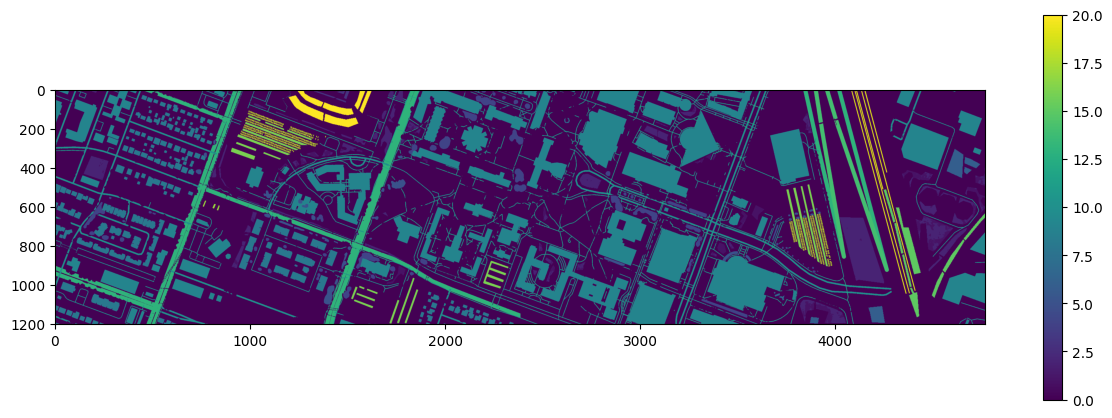

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.imshow(train_gt)
plt.colorbar()
plt.show()

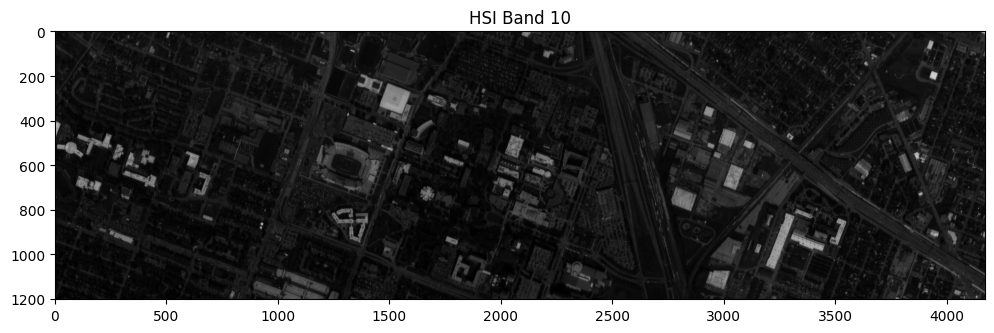

In [16]:
plt.figure(figsize=(12,5))
plt.imshow(X[:,:,10], cmap='gray')
plt.title("HSI Band 10")
plt.show()

In [17]:
train_gt_crop = train_gt[:, :4172]

print("HSI Shape     :", X.shape)
print("GT Crop Shape :", train_gt_crop.shape)

HSI Shape     : (1202, 4172, 50)
GT Crop Shape : (1202, 4172)


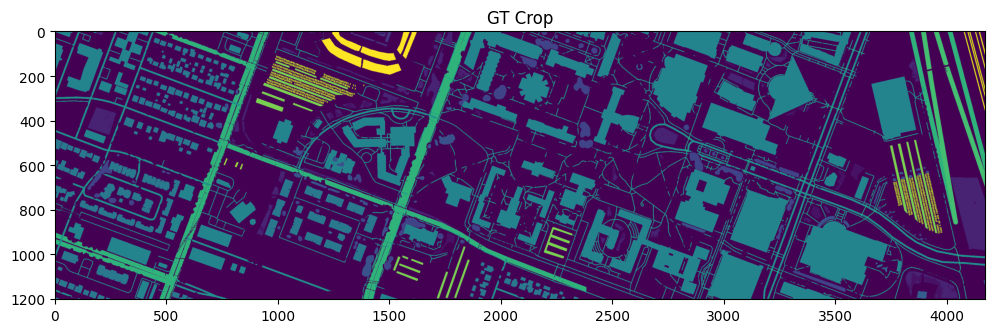

In [18]:
plt.figure(figsize=(12,5))
plt.imshow(train_gt_crop)
plt.title("GT Crop")
plt.show()

In [19]:
print(np.unique(train_gt_crop))
print("Number of classes:", len(np.unique(train_gt_crop)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20]
Number of classes: 20


In [20]:
# MEMORY SAFE NORMALIZATION

X = X.astype(np.float16)

X_min = X.min()
X_max = X.max()

X_norm = (X - X_min) / (X_max - X_min)

X_norm = X_norm.astype(np.float16)

print(X_norm.dtype)
print(X_norm.shape)

float16
(1202, 4172, 50)


In [21]:
print("Normalized Shape:", X_norm.shape)
print("Min:", X_norm.min())
print("Max:", X_norm.max())

Normalized Shape: (1202, 4172, 50)
Min: 0.0
Max: 1.0


In [22]:
valid_labels = sorted(
    np.unique(
        train_gt_crop[
            train_gt_crop > 0
        ]
    )
)

label_map = {
    old:i
    for i, old in enumerate(valid_labels)
}

print("Foreground Classes:")
print(valid_labels)

print("\nNumber of Classes:")
print(len(valid_labels))

Foreground Classes:
[np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20)]

Number of Classes:
19


In [23]:
from collections import Counter

counter = Counter(
    train_gt_crop[
        train_gt_crop > 0
    ].flatten()
)

for cls in sorted(counter):
    print(
        f"Class {cls}: {counter[cls]}"
    )

Class 1: 23700
Class 2: 96680
Class 3: 2736
Class 4: 54322
Class 5: 20172
Class 6: 1352
Class 7: 1064
Class 8: 158995
Class 9: 808845
Class 10: 170536
Class 11: 136035
Class 12: 6059
Class 13: 181545
Class 14: 33290
Class 16: 45932
Class 17: 587
Class 18: 26289
Class 19: 6093
Class 20: 27296


In [24]:
Y = train_gt_crop.copy()

print(Y.shape)
print(np.unique(Y))

(1202, 4172)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20]


In [38]:
TARGET_TOTAL = 500000

TOTAL_LABELS = np.sum(Y > 0)

selected_pixels = []

for cls in valid_labels:   # not range(1,20)

    coords = np.argwhere(Y == cls)

    n = int(
        len(coords) /
        TOTAL_LABELS *
        TARGET_TOTAL
    )

    n = max(100, n)

    idx = np.random.choice(
        len(coords),
        min(n, len(coords)),
        replace=False
    )

    selected_pixels.extend(
        [(r, c, cls)
         for r, c in coords[idx]]
    )

print("Selected Pixels:", len(selected_pixels))

Selected Pixels: 499990


In [39]:
PATCH_SIZE = 7
HALF = PATCH_SIZE // 2

X_patches = []
y_labels = []

for r, c, cls in selected_pixels:

    if (
        r < HALF or
        r >= X_norm.shape[0] - HALF or
        c < HALF or
        c >= X_norm.shape[1] - HALF
    ):
        continue

    patch = X_norm[
        r-HALF:r+HALF+1,
        c-HALF:c+HALF+1,
        :
    ]

    patch = np.transpose(
        patch,
        (2, 0, 1)
    )

    X_patches.append(
        patch.astype(np.float32)
    )

    y_labels.append(
        label_map[cls]
    )

X_patches = np.array(X_patches)
y_labels = np.array(y_labels)

print(X_patches.shape)
print(y_labels.shape)

(497141, 50, 7, 7)
(497141,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_patches,
    y_labels,
    test_size=0.60,
    stratify=y_labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Train: 198856
Val  : 149142
Test : 149143


In [41]:
import torch

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(1)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).unsqueeze(1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(y_train)
y_val = torch.tensor(y_val)
y_test = torch.tensor(y_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

torch.Size([198856, 1, 50, 7, 7])
torch.Size([149142, 1, 50, 7, 7])
torch.Size([149143, 1, 50, 7, 7])


In [42]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

1554
1166
1166


In [43]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

print("Classes:",
      torch.unique(y))

torch.Size([128, 1, 50, 7, 7])
torch.Size([128])
Classes: tensor([ 0,  1,  3,  7,  8,  9, 10, 12, 13, 14, 16, 18])


In [44]:
import torch
import torch.nn as nn

class HSI3DCNN_Attention_Transformer(nn.Module):

    def __init__(self, num_classes=19):

        super().__init__()

        # ==========================================
        # 3D CNN FEATURE EXTRACTOR
        # ==========================================
        self.features = nn.Sequential(

            nn.Conv3d(
                1, 8,
                kernel_size=(7,3,3),
                padding=(3,1,1)
            ),
            nn.BatchNorm3d(8),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                8, 16,
                kernel_size=(5,3,3),
                padding=(2,1,1)
            ),
            nn.BatchNorm3d(16),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                16, 32,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )

        # ==========================================
        # CHANNEL (SPECTRAL) ATTENTION
        # ==========================================
        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool3d(1),

            nn.Conv3d(
                32,
                8,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                8,
                32,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        self.spatial_attention = nn.Sequential(

            nn.Conv3d(
                32,
                1,
                kernel_size=3,
                padding=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # TRANSFORMER
        # ==========================================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # ==========================================
        # CLASSIFIER
        # ==========================================
        self.classifier = nn.Sequential(

            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # ==========================================
        # CNN FEATURES
        # ==========================================
        x = self.features(x)

        # ==========================================
        # CHANNEL ATTENTION
        # ==========================================
        ca = self.channel_attention(x)
        x = x * ca

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        sa = self.spatial_attention(x)
        x = x * sa

        # ==========================================
        # REAL TRANSFORMER TOKENS
        # ==========================================
        B, C, D, H, W = x.shape

        # (B,C,D,H,W) -> (B,C,N)
        x = x.view(B, C, D * H * W)

        # (B,C,N) -> (B,N,C)
        x = x.permute(0, 2, 1)

        # DEBUG
        # print("Transformer Input:", x.shape)

        # Transformer
        x = self.transformer(x)

        # Global token pooling
        x = x.mean(dim=1)

        # ==========================================
        # CLASSIFICATION
        # ==========================================
        x = self.classifier(x)

        return x

In [45]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [46]:
model = HSI3DCNN_Attention_Transformer(
    num_classes=19
).to(DEVICE)

print(model)

HSI3DCNN_Attention_Transformer(
  (features): Sequential(
    (0): Conv3d(1, 8, kernel_size=(7, 3, 3), stride=(1, 1, 1), padding=(3, 1, 1))
    (1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(8, 16, kernel_size=(5, 3, 3), stride=(1, 1, 1), padding=(2, 1, 1))
    (5): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (channel_attention): Sequential(
    (0): AdaptiveAvgPool3d(output_size=1)
    (1): Conv3d(32, 8, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (2): ReLU()
    (3): Conv3d(8

In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
   
)

In [48]:
EPOCHS = 100

best_val_acc = 0

for epoch in range(EPOCHS):

    # =====================
    # TRAIN
    # =====================

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        pred = logits.argmax(1)

        train_correct += (
            pred == y
        ).sum().item()

        train_total += y.size(0)

    train_acc = (
        100 * train_correct /
        train_total
    )

    # =====================
    # VALIDATION
    # =====================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)

            pred = logits.argmax(1)

            val_correct += (
                pred == y
            ).sum().item()

            val_total += y.size(0)

    val_acc = (
        100 * val_correct /
        val_total
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_3dcnn.pt"
        )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 01 | Train Acc: 44.63% | Val Acc: 45.46%
Epoch 02 | Train Acc: 45.32% | Val Acc: 45.86%
Epoch 03 | Train Acc: 46.02% | Val Acc: 46.41%
Epoch 04 | Train Acc: 46.45% | Val Acc: 46.73%
Epoch 05 | Train Acc: 46.79% | Val Acc: 47.20%
Epoch 06 | Train Acc: 47.21% | Val Acc: 47.85%
Epoch 07 | Train Acc: 47.68% | Val Acc: 48.06%
Epoch 08 | Train Acc: 48.25% | Val Acc: 48.78%
Epoch 09 | Train Acc: 48.78% | Val Acc: 49.44%
Epoch 10 | Train Acc: 49.21% | Val Acc: 50.24%
Epoch 11 | Train Acc: 49.73% | Val Acc: 50.36%
Epoch 12 | Train Acc: 50.19% | Val Acc: 51.05%
Epoch 13 | Train Acc: 50.57% | Val Acc: 52.01%
Epoch 14 | Train Acc: 51.02% | Val Acc: 52.36%
Epoch 15 | Train Acc: 51.29% | Val Acc: 51.03%
Epoch 16 | Train Acc: 51.68% | Val Acc: 51.77%
Epoch 17 | Train Acc: 52.04% | Val Acc: 53.59%
Epoch 18 | Train Acc: 52.39% | Val Acc: 52.97%
Epoch 19 | Train Acc: 52.48% | Val Acc: 52.56%
Epoch 20 | Train Acc: 52.90% | Val Acc: 53.85%
Epoch 21 | Train Acc: 53.03% | Val Acc: 53.43%
Epoch 22 | Tr

KeyboardInterrupt: 

In [49]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix
)

import numpy as np

model.eval()

all_pred = []
all_true = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        logits = model(x)

        pred = logits.argmax(1)

        all_pred.extend(
            pred.cpu().numpy()
        )

        all_true.extend(
            y.numpy()
        )

OA = accuracy_score(
    all_true,
    all_pred
)

cm = confusion_matrix(
    all_true,
    all_pred
)

AA = np.mean(
    cm.diagonal() /
    cm.sum(axis=1)
)

Kappa = cohen_kappa_score(
    all_true,
    all_pred
)

print(f"OA: {OA*100:.2f}%")
print(f"AA: {AA*100:.2f}%")
print(f"Kappa: {Kappa:.4f}")

OA: 65.64%
AA: 40.06%
Kappa: 0.5091


In [37]:
from collections import Counter

print("Total samples:", len(y_labels))
print()

counter = Counter(y_labels)

for cls in sorted(counter.keys()):
    print(f"Class {cls}: {counter[cls]}")

Total samples: 397721

Class 0: 5262
Class 1: 21292
Class 2: 556
Class 3: 12044
Class 4: 4478
Class 5: 279
Class 6: 236
Class 7: 35062
Class 8: 178733
Class 9: 37528
Class 10: 30074
Class 11: 1345
Class 12: 40060
Class 13: 7318
Class 14: 10197
Class 15: 130
Class 16: 5837
Class 17: 1264
Class 18: 6026


In [ ]:
x, y = next(iter(train_loader))

x = x.to(DEVICE)

with torch.no_grad():
    logits = model(x)

pred = logits.argmax(1)

print(torch.bincount(pred.cpu()))